In [22]:
!pip install openpyxl

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import pandas as pd; df = pd.read_excel(r"C:\Users\kasar\OneDrive\Documents\PROJECTS\Online Retail.xlsx")


In [25]:
print("Shape:",df.shape)

Shape: (541909, 8)


In [26]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [104]:
df = df[(df.Quantity>0) & (df.UnitPrice > 0) & df.CustomerID.notna()]
df = df[df.Country == 'United Kingdom']
df['Total-Sales'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df.CustomerID.astype(int)
df['InvoiceDate'] = pd.to_datetime(df.InvoiceDate)
print("Clean shape:",df.shape)
df.to_csv('clean_data.csv', index=False)

Clean shape: (354321, 11)


In [105]:
from datetime import timedelta
df['Total_Sales'] = df['Quantity'] * df['UnitPrice'] #tsc

current_date = df['InvoiceDate'].max() + timedelta(days=1) #calcualted rfm

rfm_table = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total_Sales': 'sum'
}).round(2)

rfm_table.columns = ['Recency', 'Frequency', 'Monetary'] #renaming columns

rfm_table = rfm_table[(rfm_table['Recency'] < 365) & (rfm_table['Frequency'] > 0)] # excluding people who haven't bought in over a year

print(f"RFM table: {len(rfm_table)} customers")
rfm_table.head()

RFM table: 3851 customers


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12747,2,11,4196.01
12748,1,209,33719.73
12749,4,5,4090.88
12820,3,4,942.34


In [106]:
 #appliying rfm  scoring (1 to 5 scale)
rfm_table['R_Score'] = pd.qcut(rfm_table['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1])
rfm_table['F_Score'] = pd.qcut(rfm_table['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_table['M_Score'] = pd.qcut(rfm_table['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
#final score
rfm_table['RFM_Score'] = rfm_table['R_Score'].astype(str) + rfm_table['F_Score'].astype(str) + rfm_table['M_Score'].astype(str)
display(rfm_table[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head())

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12346,1,1,5,115
12747,5,5,5,555
12748,5,5,5,555
12749,5,4,5,545
12820,5,4,4,544


In [107]:
#k means clustering (ml segmentation )
features = rfm_table[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_table['Cluster'] = kmeans.fit_predict(features_scaled)

rfm_table.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean
print("ml clustering complete")

,Recency,Frequency,Monetary
Cluster,,,
0,39.890222,4.438758,1588.222072
1,3.333333,36.000000,207560.196667
2,12.173077,43.788462,31172.218462
3,230.814123,1.642783,562.758276


In [113]:
rfm_table['Churn_Risk'] = np.where(rfm_table['Recency'] > 90, 'High', 'Low')
rfm_table['CLV'] = (rfm_table['Monetary'] / rfm_table['Frequency']) * 5 * 0.3
print("Metrics added")
rfm_table[['Churn_Risk', 'CLV']].head()


# applied basic CLV Formula: (Average Order Value) * (Purchase Frequency) * (Avg Lifespan ~5 years) * Profit Margin (~30%)

Metrics added


,Churn_Risk,CLV
CustomerID,,
12346,High,115775.400000
12747,Low,572.183182
12748,Low,242.007632
12749,Low,1227.264000
12820,Low,353.377500


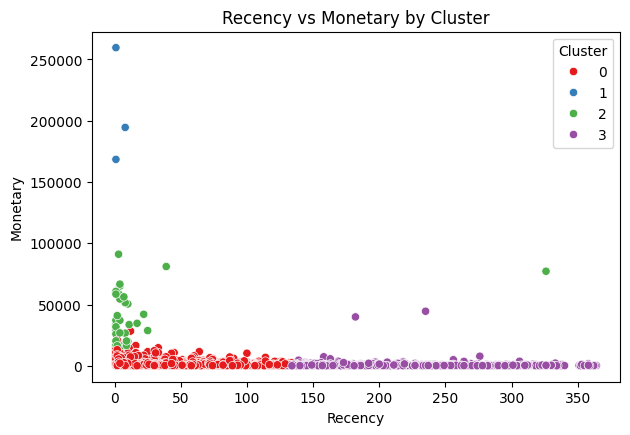

In [114]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.scatterplot(data=rfm_table, x='Recency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Recency vs Monetary by Cluster')
plt.show()


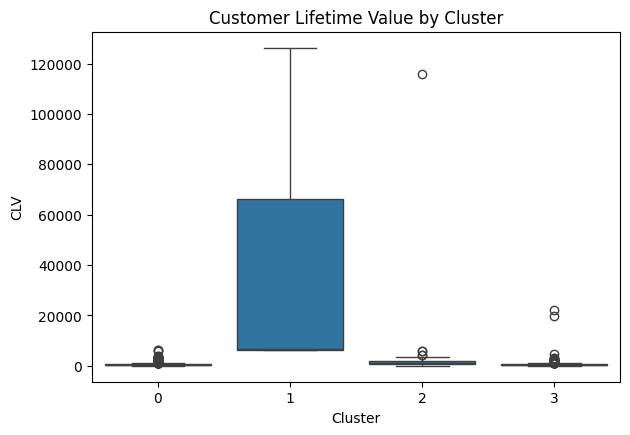

In [115]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 2)
sns.boxplot(data=rfm_table, x='Cluster', y='CLV')
plt.title('Customer Lifetime Value by Cluster')
plt.show()

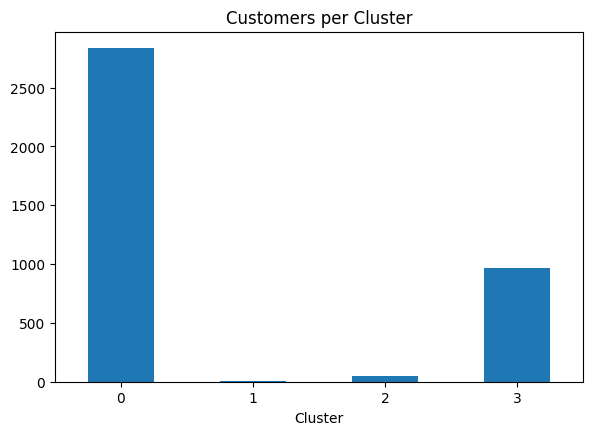

In [116]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 3)
rfm_table['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Customers per Cluster')
plt.xticks(rotation=0)
plt.show()

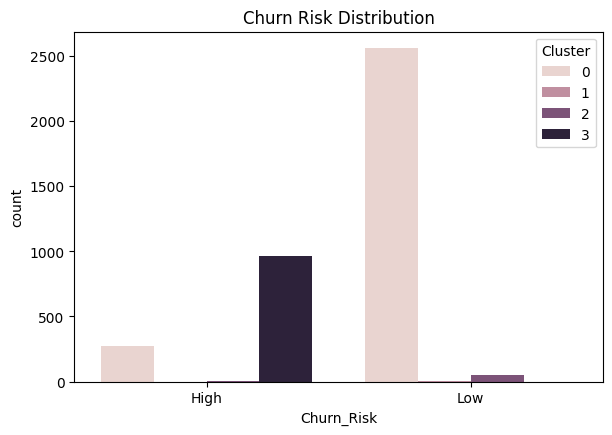

In [124]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 4)
sns.countplot(data=rfm_table, x='Churn_Risk', hue='Cluster')
plt.title('Churn Risk Distribution')
plt.xticks(rotation=0)


plt.savefig('final_project.png', dpi=300, bbox_inches='tight') 
plt.show()

In [125]:
import os
print(os.getcwd())

C:\Users\kasar\myproject
